## This will be used to explore data.
### It will access each bird species in terms of:
- Recording count
- Average quality
- Count of recording qualities
- Average length of recordings


In [2]:
import json
import pandas as pd


# Load bird species list and convert to DataFrame
with open("../../species_list_small.json", "r") as f:
    bird_list = json.load(f)

rankings = bird_list.keys()
birds = bird_list.values()
birds_df = pd.DataFrame(birds, index=rankings)
birds_df

,common_name,sci_name
1,European Robin,Erithacus rubecula
2,Eurasian Blackbird,Turdus merula
3,Eurasian Wren,Troglodytes troglodytes
4,Eurasian Blue Tit,Cyanistes caeruleus
5,Great Tit,Parus major
6,European Goldfinch,Carduelis carduelis
7,Common Chaffinch,Fringilla coelebs
8,Song Thrush,Turdus philomelos
9,Eurasian Magpie,Pica pica
10,Eurasian Jackdaw,Coloeus monedula


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
XENO_CANTO_API_KEY = os.environ.get('XENO_CANTO_API_KEY')
print("Xeno-Canto API Key loaded:", XENO_CANTO_API_KEY)

Xeno-Canto API Key loaded: d15cad7bdbfb958edb8a549a81aae802462ae7fd


In [4]:
import time
import requests


def _get_with_retry(url, params, max_retries=3):
    last_exception = None

    for attempt in range(max_retries):
        try:
            resp = requests.get(url, params=params)
            resp.raise_for_status()
            return resp.json()
        except Exception as e:
            last_exception = e
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)  # Exponential backoff
    raise last_exception

In [5]:
BASE_URL = "https://xeno-canto.org/api/3/recordings"

def get_recordings_data_for_species(sci_name, per_page=500):
    all_recordings = []
    page = 1

    while True:
        params = {
            "query": f'sp:"{sci_name}"',
            "page": page,
            "per_page": per_page,
            "key": XENO_CANTO_API_KEY
        }

        data = _get_with_retry(BASE_URL, params)
        all_recordings.extend(data["recordings"])

        if page >= data.get("numPages", 1):
            break
        page += 1
    return all_recordings

#### For each species recordings list:
- Total count
- Total european count
- Average recording length
- Location counts (object)
- Quality counts (object)



In [6]:
# Simple list of European countries for filtering
europe_countries = [
    "United Kingdom", "Ireland", "France", "Germany", "Spain", "Portugal",
    "Italy", "Netherlands", "Belgium", "Switzerland", "Austria", "Denmark",
    "Sweden", "Norway", "Finland", "Poland", "Czech Republic", "Slovakia",
    "Hungary", "Greece", "Romania", "Bulgaria", "Croatia", "Slovenia",
    "Estonia", "Latvia", "Lithuania", "Luxembourg", "Liechtenstein",
    "Iceland", "Malta"
]


In [7]:
def _xeno_length_to_seconds(s):
    if not s or ":" not in s:
        return None
    
    parts = s.split(":")

    parts = list(map(int, parts))
    if len(parts) == 2:  # MM:SS
        m, sec = parts
        return m*60 + sec
    elif len(parts) == 3:  # H:MM:SS (rare)
        h, m, sec = parts
        return h*3600 + m*60 + sec

In [8]:
from collections import Counter

# Need to iterate through the pandas DataFrame and collect stats for each species
species_stats = {}

for bird in birds_df.itertuples():
    sci_name = bird.sci_name
    common_name = bird.common_name
    recordings = get_recordings_data_for_species(sci_name) ## get all recordings for species

    total_count = len(recordings)
    european_count = sum(1 for rec in recordings if rec['cnt'] in europe_countries)

    lens = [r.get("length") for r in recordings]
    lengths = [_xeno_length_to_seconds(r.get("length")) for r in recordings]
    lengths = [round(x) for x in lengths if x is not None]
    avg_length = round(sum(lengths) / len(lengths)) if lengths else 0.0

    q_counts = Counter(r.get("q") for r in recordings if r.get("q"))
    quality_counts = {k: q_counts.get(k, 0) for k in ["A", "B", "C", "D", "E"]}
    
    c_counts = Counter(r.get("cnt") for r in recordings if r.get("cnt"))
    country_counts = dict(sorted(c_counts.items(), key=lambda item: item[1], reverse=True)[:10]) ## limit to top 10 countries

    species_stats[sci_name] = {
        "total_count": total_count,
        "european_count": european_count,
        "avg_length": avg_length,
        "quality_counts": quality_counts,
        "country_counts": country_counts,
        "lengths": lengths
    }

    print(f"{common_name} ({sci_name}): {species_stats[sci_name]}")


European Robin (Erithacus rubecula): {'total_count': 7570, 'european_count': 7178, 'avg_length': 139, 'quality_counts': {'A': 920, 'B': 3462, 'C': 2580, 'D': 468, 'E': 140}, 'country_counts': {'France': 1418, 'United Kingdom': 1256, 'Germany': 832, 'Spain': 799, 'Portugal': 526, 'Poland': 416, 'Netherlands': 395, 'Ireland': 289, 'Sweden': 287, 'Italy': 246}, 'lengths': [51, 24, 92, 46, 58, 47, 169, 337, 121, 73, 203, 317, 44, 41, 17, 94, 229, 122, 92, 100, 78, 27, 282, 297, 55, 146, 25, 24, 37, 194, 97, 103, 17, 209, 8, 78, 21, 161, 38, 57, 169, 31, 22, 18, 217, 168, 115, 220, 117, 134, 84, 30, 25, 249, 76, 120, 283, 287, 104, 92, 36, 90, 52, 307, 87, 141, 81, 60, 973, 228, 61, 43, 217, 194, 41, 79, 77, 134, 303, 243, 110, 129, 161, 118, 330, 28, 134, 123, 188, 300, 70, 110, 203, 39, 41, 41, 44, 169, 128, 63, 43, 23, 74, 12, 39, 137, 139, 42, 73, 25, 27, 177, 51, 114, 63, 46, 53, 570, 112, 488, 219, 165, 104, 23, 232, 62, 52, 63, 84, 347, 206, 309, 110, 3, 120, 37, 189, 238, 151, 228, 

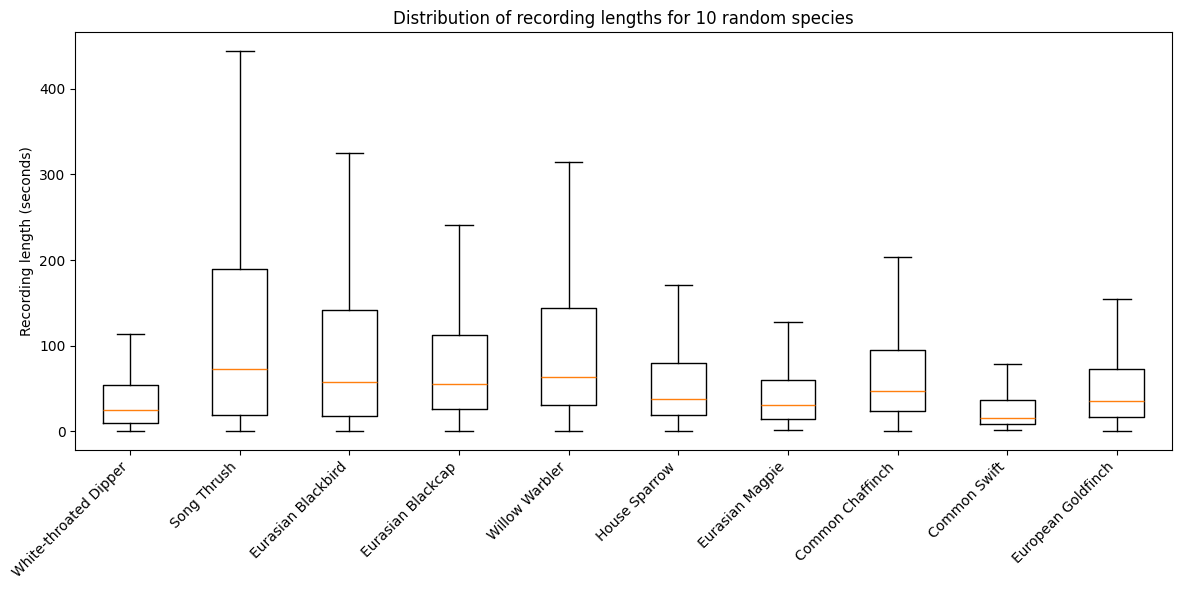

In [ ]:
import random
import matplotlib.pyplot as plt

random.seed(42)

candidates = [k for k, v in species_stats.items() if v["lengths"]]
chosen = random.sample(candidates, min(10, len(candidates)))

common_by_sci = {row.sci_name: row.common_name for row in birds_df.itertuples()}
labels = [common_by_sci.get(s, s) for s in chosen]

data = [species_stats[s]["lengths"] for s in chosen]

plt.figure(figsize=(12, 6))
plt.boxplot(data, showfliers=False)
plt.xticks(range(1, len(chosen) + 1), labels, rotation=45, ha="right")
plt.ylabel("Recording length (seconds)")
plt.title("Distribution of recording lengths for 10 random species")
plt.tight_layout()
plt.show()


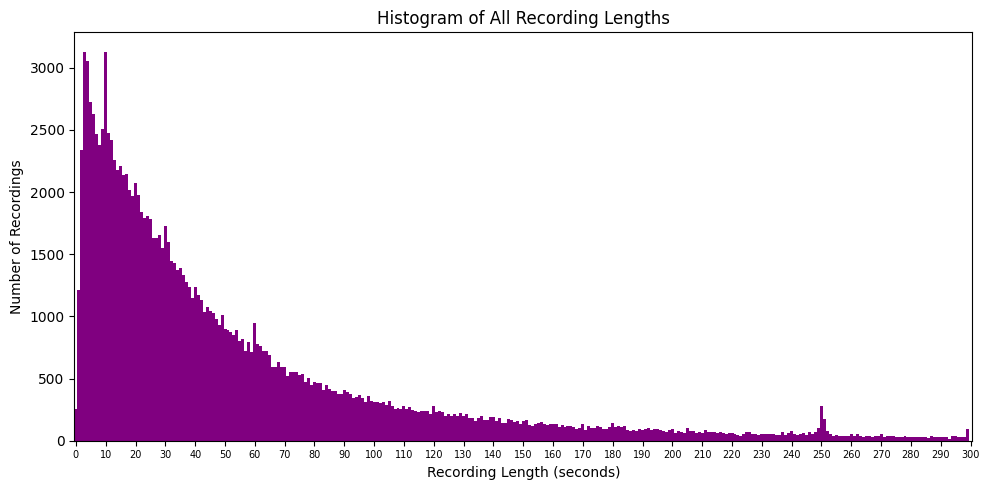

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

all_lengths = []
for stats in species_stats.values():
    all_lengths.extend(stats["lengths"])

vals = [x for x in all_lengths if 0 <= x <= 300]

bins = np.arange(0, 301, 1)  

plt.figure(figsize=(10, 5))
plt.hist(vals, bins=bins, align='left', color='purple')
plt.xlabel("Recording Length (seconds)")
plt.ylabel("Number of Recordings")
plt.title("Histogram of All Recording Lengths")
plt.xlim(-0.5, 300.5)               
plt.xticks(np.arange(0, 301, 10), fontsize=7)  
plt.tight_layout()
plt.show()


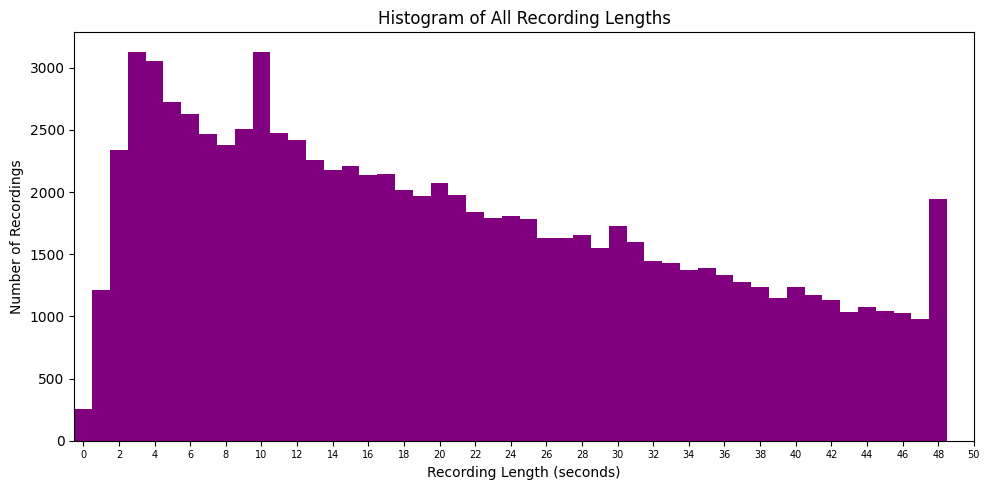

In [11]:

bins = np.arange(0, 50, 1)  

plt.figure(figsize=(10, 5))
plt.hist(vals, bins=bins, align='left', color='purple')
plt.xlabel("Recording Length (seconds)")
plt.ylabel("Number of Recordings")
plt.title("Histogram of All Recording Lengths")
plt.xlim(-0.5, 50)               # show full first/last bin
plt.xticks(np.arange(0, 51, 2), fontsize=7)   # ticks every 10s
plt.tight_layout()
plt.show()

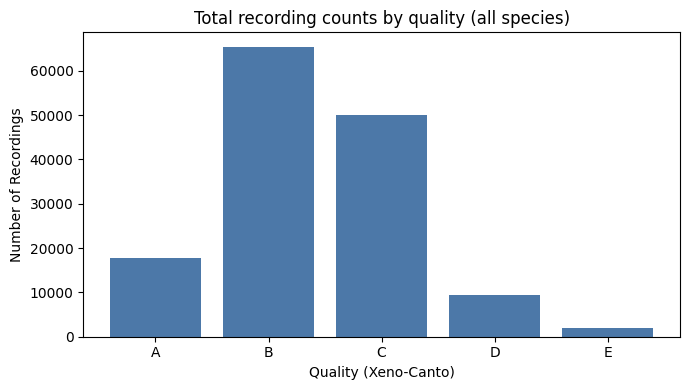

In [12]:
from collections import Counter
import matplotlib.pyplot as plt

quality_totals = Counter()
for stats in species_stats.values():
    quality_totals.update(stats.get("quality_counts", {}))

qualities = ["A", "B", "C", "D", "E"]
counts = [quality_totals.get(q, 0) for q in qualities]

plt.figure(figsize=(7, 4))
plt.bar(qualities, counts, color="#4C78A8")
plt.xlabel("Quality (Xeno-Canto)")
plt.ylabel("Number of Recordings")
plt.title("Total recording counts by quality (all species)")
plt.tight_layout()
plt.show()
